# MIRIPVIR25 - Draft 00 - Detection statistics

## Summary

In [1]:
from rdflib import Graph
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

## Detections

In [3]:
data = Graph()
data.parse(open("data/miripvir.2025-07-09.ttl"))

<Graph identifier=N36df48f004be46f5b1ade3006c34538e (<class 'rdflib.graph.Graph'>)>

## How many detections in total?

In [4]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT (COUNT(?hit) AS ?nhits)
WHERE {
    ?hit mvront:BelongsTo mvrcol:0000 .
}


"""
)
res = pd.DataFrame(res, columns=list(map(str, res.vars)))
res

,nhits
0,1504


## How many detections per library?

In [5]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#> 
PREFIX emi: <https://purl.org/emi#>

SELECT  ?library ?site ?habitat (COUNT(?hit) AS ?number_hits)
WHERE {
    
    
    ?l rdfs:label ?library .
    ?l mvront:Sampled_from ?s .
    ?s a mvront:Site .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat .
    OPTIONAL {
        ?l mvront:Reported ?hit .
        ?hit a emi:Organism .
        ?hit mvront:BelongsTo mvrcol:0000 .
    }
} GROUP BY ?library

"""
)
res = pd.DataFrame(res, columns=list(map(str, res.vars)))
res['number_hits'] = res['number_hits'].astype(int) 
res['habitat'] = res['habitat'].astype(str) 
res

,library,site,habitat,number_hits
0,PV534,C1,Crop,1
1,PV535,C1,Crop,3
2,PV538,C1,Crop,1
3,PV540,C1,Crop,0
4,PV544,C1,Crop,11
...,...,...,...,...
318,PV590,Z1,Crop,0
319,PV047,Z2,Crop,5
320,PV048,Z2,Crop,2
321,PV527,Z2,Crop,116


In [6]:
len(res.query('number_hits > 0'))


296

In [7]:
len(res.query('number_hits == 1'))


87

In [8]:
len(res.query('number_hits >= 5'))


70

In [9]:
len(res.query('number_hits >= 10'))


26

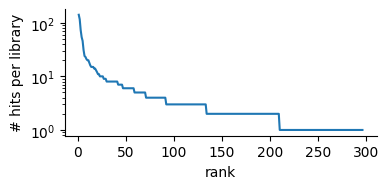

In [10]:
res_ = res.sort_values(by='number_hits', ascending=False).query('number_hits > 0')
res_['rank'] = np.arange(1, len(res_) + 1)
g = sns.relplot(
    data=res_,
    x='rank', y='number_hits', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("rank")
g.set_ylabels("# hits per library")

In [11]:
res
res['habitat'] = res['habitat'].apply(lambda x: str(x))

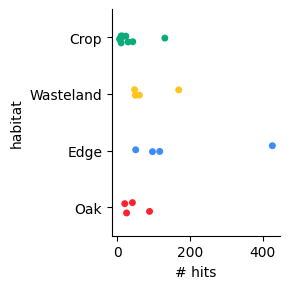

In [12]:
g = sns.catplot(
    data=res.groupby(['site', 'habitat'], as_index=False)['number_hits'].sum(), y='habitat', x='number_hits', hue='habitat', 
    palette=habitat_palette, height=3.0,
)
g.set_xlabels("# hits")

In [13]:
from scipy import stats

In [14]:
stats.kruskal(
    res.groupby(['site', 'habitat'], as_index=False)['number_hits'].sum().query('habitat == "Crop"')['number_hits'],
    res.groupby(['site', 'habitat'], as_index=False)['number_hits'].sum().query('habitat == "Wasteland"')['number_hits'],
    res.groupby(['site', 'habitat'], as_index=False)['number_hits'].sum().query('habitat == "Edge"')['number_hits'],
    res.groupby(['site', 'habitat'], as_index=False)['number_hits'].sum().query('habitat == "Oak"')['number_hits'],

)

KruskalResult(statistic=12.011863568956992, pvalue=0.007342631221994296)

In [15]:
u = pd.merge(
    res.groupby(['site'], as_index=False)['number_hits'].sum(),
    res.value_counts(['site', 'habitat']).reset_index(), on='site'
)
u['avg_hits'] = u['number_hits'] / u['count']
u

,site,number_hits,habitat,count,avg_hits
0,C1,16,Crop,5,3.200000
1,C2,30,Crop,6,5.000000
2,E1,48,Wasteland,14,3.428571
3,E2,50,Wasteland,18,2.777778
4,E3,61,Wasteland,13,4.692308
5,E4,169,Wasteland,19,8.894737
6,H1,8,Crop,4,2.000000
7,H2,15,Crop,4,3.750000
8,H3,11,Crop,5,2.200000
9,L1,117,Edge,40,2.925000


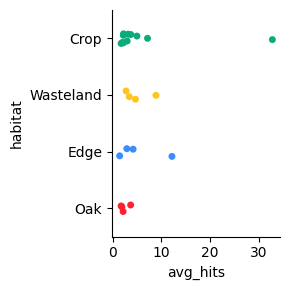

In [16]:
sns.catplot(
    data=u, y='habitat', x='avg_hits', hue='habitat', 
    palette=habitat_palette, height=3.0,
)

In [17]:
stats.linregress(u['count'], u['number_hits'])

LinregressResult(slope=4.739700723355375, intercept=-1.2575362453819992, rvalue=0.593926085564754, pvalue=0.002807684530262403, stderr=1.4010237828747074, intercept_stderr=25.023084886112603)

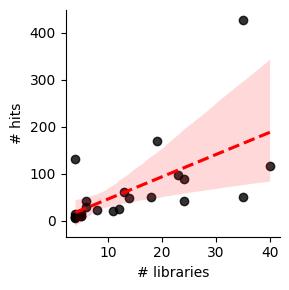

In [18]:
g = sns.lmplot(u, x='count', y='number_hits', height=3., scatter_kws={'color':'black'}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("# libraries")
g.set_ylabels("# hits")

In [19]:
res['is_positive'] = res['number_hits'] > 0

coverage_bysite = pd.merge(
    res.groupby(['site', 'habitat'], as_index=False)['is_positive'].sum(),
    res.groupby('site', as_index=False)['is_positive'].apply(len),
    on='site'
).rename(columns={'is_positive_x': 'positives', 'is_positive_y': 'total'})
coverage_bysite['ratio'] = coverage_bysite['positives'] / coverage_bysite['total']
coverage_bysite

,site,habitat,positives,total,ratio
0,C1,Crop,4,5,0.800000
1,C2,Crop,6,6,1.000000
2,E1,Wasteland,14,14,1.000000
3,E2,Wasteland,13,18,0.722222
4,E3,Wasteland,13,13,1.000000
5,E4,Wasteland,19,19,1.000000
6,H1,Crop,4,4,1.000000
7,H2,Crop,4,4,1.000000
8,H3,Crop,5,5,1.000000
9,L1,Edge,37,40,0.925000


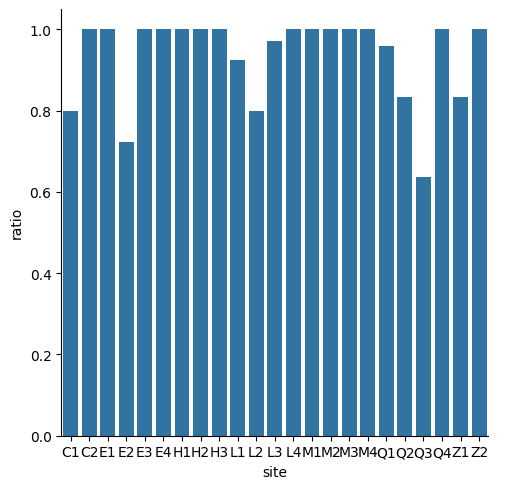

In [20]:
sns.catplot(data=coverage_bysite, y='ratio', x='site', kind='bar')

In [21]:
coverage_bysite

,site,habitat,positives,total,ratio
0,C1,Crop,4,5,0.800000
1,C2,Crop,6,6,1.000000
2,E1,Wasteland,14,14,1.000000
3,E2,Wasteland,13,18,0.722222
4,E3,Wasteland,13,13,1.000000
5,E4,Wasteland,19,19,1.000000
6,H1,Crop,4,4,1.000000
7,H2,Crop,4,4,1.000000
8,H3,Crop,5,5,1.000000
9,L1,Edge,37,40,0.925000


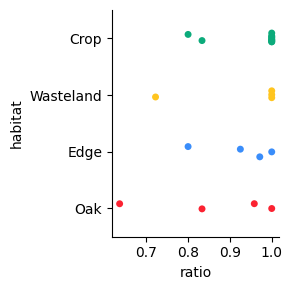

In [22]:
sns.catplot(data=coverage_bysite, x='ratio', y='habitat', hue='habitat', height=3.0, palette=habitat_palette)

## How many hits per taxon?

In [23]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT (COUNT(?host) AS ?number_hosts)
WHERE {
    ?host a mvront:Host
    
}


"""
)
res = pd.DataFrame(res, columns=list(map(str, res.vars)))
res

,number_hosts
0,119


In [24]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dwc: <http://rs.tdwg.org/dwc/terms/>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT  (COUNT(DISTINCT($taxon)) AS ?n_taxon)
WHERE {
    ?organism uniprotrdfs:Taxon ?taxon .
    ?organism mvront:BelongsTo mvrcol:0000 .  
}


"""
)
res = pd.DataFrame(res, columns=list(map(str, res.vars)))
res

,n_taxon
0,523


In [25]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dwc: <http://rs.tdwg.org/dwc/terms/>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>

SELECT ?scientific_name (COUNT($lib) AS ?n_libraries)
WHERE {
    ?taxon a emi:Taxon . 
    ?taxon dwc:scientificName ?scientific_name .
    ?organism uniprotrdfs:Taxon ?taxon .
    ?organism mvront:BelongsTo mvrcol:0000 .
    ?lib mvront:Reported $organism
    

} GROUP BY $scientific_name


"""
)
res = pd.DataFrame(res, columns=list(map(str, res.vars)))
res['n_libraries'] = res['n_libraries'].astype(int)
res

,scientific_name,n_libraries
0,Mycoplasmoides genitalium,12
1,uncultured Clostridium sp.,252
2,Candidatus Phytoplasma solani,4
3,Neisseria sp. oral taxon 014,3
4,Janthinobacterium sp. B9-8,15
...,...,...
516,Arthrobacter sp. OY3WO11,1
517,Hymenobacter sp. CRA2,1
518,Holzapfeliella floricola,1
519,Apilactobacillus ozensis,1


In [26]:
res['n_libraries'].sum()

1504

In [27]:
res = res.sort_values(by='n_libraries', ascending=False)
res['n_libraries'] = res['n_libraries'].apply(int) 
res['rank'] = np.arange(len(res))

In [28]:
def gini(x):
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

In [29]:
gini(res['n_libraries'])

0.5582094580797975

In [30]:
res.sort_values(by='n_libraries')

,scientific_name,n_libraries,rank
379,Roseomonas mucosa,1,260
469,Rhodopseudomonas palustris,1,354
9,Sphingomonas koreensis,1,353
472,Glutamicibacter halophytocola,1,352
473,Sphingopyxis sp. LC363,1,351
...,...,...,...
45,Pseudomonas lutea,21,4
43,Rhodococcoides fascians,22,3
59,Frigoribacterium sp. Leaf164,26,2
62,Clavibacter michiganensis,28,1


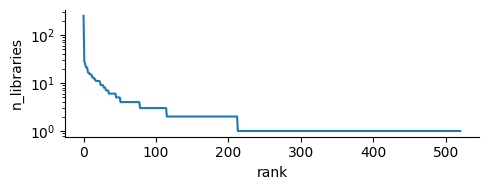

In [31]:
g = sns.relplot(
    data=res, y='n_libraries', x='rank', kind='line',
    height=2.0, aspect=2.5
)
g.ax.set_yscale('log')

In [32]:
res['%'] = res['n_libraries'] / 1504

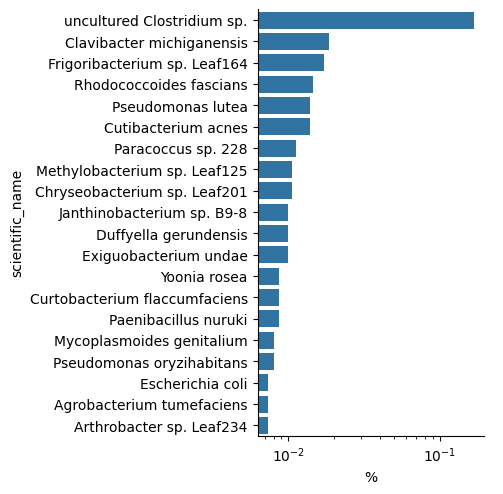

In [33]:
g = sns.catplot(
    data=res[:20], y='scientific_name', x='%', kind='bar'
)
g.ax.set_xscale('log')

In [34]:
total_20 = res[:19]['%'].sum()
res['scientific_name'] = res['scientific_name'].apply(lambda x: str(x))
m = res[['scientific_name', '%']][:19].to_dict(orient='records')
m.append(
    {'scientific_name': 'others', '%': 1- total_20}
)
m = pd.DataFrame.from_records(
    m
)
m

,scientific_name,%
0,uncultured Clostridium sp.,0.167553
1,Clavibacter michiganensis,0.018617
2,Frigoribacterium sp. Leaf164,0.017287
3,Rhodococcoides fascians,0.014628
4,Pseudomonas lutea,0.013963
5,Cutibacterium acnes,0.013963
6,Paracoccus sp. 228,0.011303
7,Methylobacterium sp. Leaf125,0.010638
8,Chryseobacterium sp. Leaf201,0.010638
9,Janthinobacterium sp. B9-8,0.009973


([<matplotlib.patches.Wedge at 0x14cbb29717c0>,
 [Text(0.9510924553609713, 0.552651012263109, ''),
  Text(0.4878909536841407, 0.9858815432460332, ''),
  Text(0.3738221394794791, 1.0345322653426452, ''),
  Text(0.26839251322971447, 1.0667546385379525, ''),
  Text(0.17162404971144654, 1.0865289621361425, ''),
  Text(0.07576434743342438, 1.097387699793463, ''),
  Text(-0.01148829133447894, 1.0999400070741197, ''),
  Text(-0.08722118554964338, 1.0965365770421498, ''),
  Text(-0.16026697373080956, 1.088262145409445, ''),
  Text(-0.2303507125984803, 1.0756107796063465, ''),
  Text(-0.29725735254816266, 1.0590741552677307, ''),
  Text(-0.36299708335501746, 1.0383800448177685, ''),
  Text(-0.42307361572843766, 1.0153859934401628, ''),
  Text(-0.4775677849697881, 0.990923312249263, ''),
  Text(-0.530653706568745, 0.9635386051969337, ''),
  Text(-0.5802240461614087, 0.9345266482321859, ''),
  Text(-0.626324969664055, 0.9042770772143462, ''),
  Text(-0.6690297384092656, 0.873154745233644, ''),
  

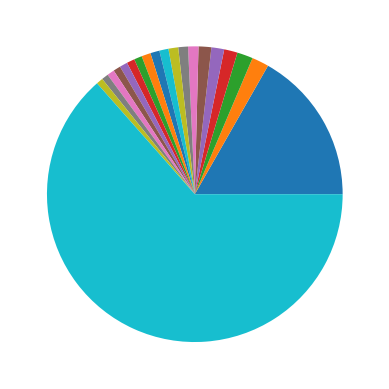

In [35]:
plt.pie(
    m['%']
)

In [36]:
m.query('scientific_name != "others"').query('scientific_name != "uncultured Clostridium sp."')['scientific_name']

1         Clavibacter michiganensis
2      Frigoribacterium sp. Leaf164
3           Rhodococcoides fascians
4                 Pseudomonas lutea
5               Cutibacterium acnes
6                Paracoccus sp. 228
7      Methylobacterium sp. Leaf125
8      Chryseobacterium sp. Leaf201
9        Janthinobacterium sp. B9-8
10            Duffyella gerundensis
11            Exiguobacterium undae
12                     Yoonia rosea
13    Curtobacterium flaccumfaciens
14             Paenibacillus nuruki
15        Mycoplasmoides genitalium
16        Pseudomonas oryzihabitans
17                 Escherichia coli
18        Agrobacterium tumefaciens
Name: scientific_name, dtype: object

In [37]:
m.query('scientific_name == "uncultured Clostridium sp."')

,scientific_name,%
0,uncultured Clostridium sp.,0.167553


([<matplotlib.patches.Wedge at 0x14cbb27b0760>,
 [Text(1.0521051882453194, 0.3210524456646937, 'Clavibacter michiganensis'),
  Text(0.7115131944779586, 0.8388974753113582, 'Frigoribacterium sp. Leaf164'),
  Text(0.21388619837430167, 1.079005418959974, 'Rhodococcoides fascians'),
  Text(-0.2818900243242658, 1.0632676117452582, 'Pseudomonas lutea'),
  Text(-0.7115129784839973, 0.838897658507181, 'Cutibacterium acnes'),
  Text(-0.9829958044229807, 0.49367929720296894, 'Paracoccus sp. 228'),
  Text(-1.0925621635145417, 0.12770246221754547, 'Methylobacterium sp. Leaf125'),
  Text(-1.0729728301477564, -0.24234130016304353, 'Chryseobacterium sp. Leaf201'),
  Text(-0.9377523300978516, -0.5749961455488636, 'Janthinobacterium sp. B9-8'),
  Text(-0.7115134006539688, -0.838897300442566, 'Duffyella gerundensis'),
  Text(-0.41422434671897895, -1.0190280617260916, 'Exiguobacterium undae'),
  Text(-0.09876921169313771, -1.095556772979619, 'Yoonia rosea'),
  Text(0.20246041172273793, -1.081207557171637

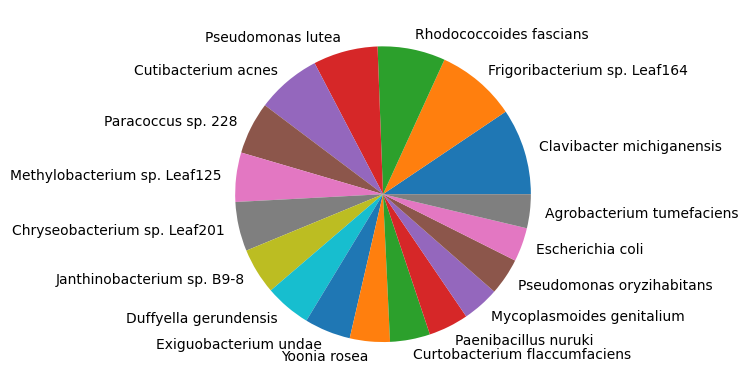

In [38]:
plt.pie(
    m.query('scientific_name != "others"').query('scientific_name != "uncultured Clostridium sp."')['%'],
    labels=m.query('scientific_name != "others"').query('scientific_name != "uncultured Clostridium sp."')['scientific_name']
)

In [39]:
res.query('n_libraries == 1')

,scientific_name,n_libraries,rank,%
435,Arthrobacter nitrophenolicus,1,213,0.000665
436,Bacillus atrophaeus,1,214,0.000665
372,Microbacterium sp. 69-10,1,215,0.000665
415,Dyadobacter psychrophilus,1,216,0.000665
22,Flavobacterium subsaxonicum,1,217,0.000665
...,...,...,...,...
307,Geodermatophilus obscurus,1,516,0.000665
305,Klenkia marina,1,517,0.000665
304,Demequina soli,1,518,0.000665
72,Novosphingobium mathurense,1,519,0.000665


## Plant-Associated Bacteria hits 

In [45]:
res = data.query(
"""
PREFIX mvrtaxon: <http://localhost:8000/taxon/>
PREFIX mvrlib: <http://localhost:8000/library/>
PREFIX mvront: <http://localhost:8000/ont/>
PREFIX mvrcol: <http://localhost:8000/collection/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dwc: <http://rs.tdwg.org/dwc/terms/>
PREFIX uniprotrdfs: <http://purl.uniprot.org/core/>
PREFIX wlo: <http://purl.org/ontology/wo/>

SELECT ?scientific_name ?taxid ?library ?site ?habitat ?pab_type
WHERE {
    ?organism mvront:BelongsTo mvrcol:0000 .
    ?organism uniprotrdfs:Taxon ?taxon .
    ?taxon mvront:is_pab "true" .
    ?taxon mvront:pab_type ?pab_type .
    ?taxon dwc:scientificName ?scientific_name .
    ?taxon dwc:taxonID ?taxid .
    ?taxon a emi:Taxon .
    ?lib mvront:Reported $organism .
    ?lib rdfs:label ?library .
    ?lib mvront:Sampled_from ?s .
    ?s rdfs:label ?site .
    ?s wlo:habitat ?habitat 
}
"""
)
pab_hits = pd.DataFrame(res, columns=list(map(str, res.vars)))
pab_hits['taxid'] = pab_hits['taxid'].apply(int)
pab_hits['scientific_name'] = pab_hits['scientific_name'].apply(str)
pab_hits['library'] = pab_hits['library'].apply(str)
pab_hits['site'] = pab_hits['site'].apply(str)
pab_hits['habitat'] = pab_hits['habitat'].apply(str)
pab_hits['pab_type'] = pab_hits['pab_type'].apply(str)
pab_hits

,scientific_name,taxid,library,site,habitat,pab_type
0,Bradyrhizobium elkanii,29448,PV003bgi,M1,Crop,pab_symbiont
1,Bradyrhizobium elkanii,29448,PV004bgi,M1,Crop,pab_symbiont
2,Bradyrhizobium elkanii,29448,PV005bgi,Q1,Oak,pab_symbiont
3,Bradyrhizobium elkanii,29448,PV007bgi,Q1,Oak,pab_symbiont
4,Bradyrhizobium elkanii,29448,PV012bgi,M2,Crop,pab_symbiont
...,...,...,...,...,...,...
436,Kribbella sp. ALI-6-A,1933817,PV527,Z2,Crop,pab_unknown
437,Rhizobium sp. NFR07,1566262,PV527,Z2,Crop,pab_symbiont
438,Devosia elaeis,1770058,PV527,Z2,Crop,pab_unknown
439,Sphingomonas sp. Leaf17,1735683,PV544,C1,Crop,pab_unknown


In [96]:
sanchis21 = pd.read_csv("data/sanchis21.tableS1.csv", sep="\t").drop_duplicates('TaxId', keep='first')
sanchis21['PAB_type'] = sanchis21.apply(lambda x: 'pathogen' if x['PAB-phyto'] == 'P' else "unknown", axis=1)
sanchis21['PAB_type'] = sanchis21.apply(lambda x: 'symbiont' if x['PAB-symb'] == 'S' else x['PAB_type'], axis=1)
sanchis21

,TaxId,Biosample,Representative species,PAB-phyto,PAB-symb,PAB_type
0,178901,SAMN02849420,Acetobacter malorum,NaN,NaN,unknown
1,441768,SAMN02603756,Acholeplasma laidlawii PG-8A,NaN,NaN,unknown
2,32002,SAMN06198582,Achromobacter denitrificans,NaN,NaN,unknown
3,217204,SAMN06174288,Achromobacter insolitus,NaN,NaN,unknown
4,72556,SAMN03941583,Achromobacter piechaudii,NaN,NaN,unknown
...,...,...,...,...,...,...
955,698414,SAMN06765826,Xylella fastidiosa subsp. pauca,P,NaN,pathogen
956,1444770,SAMN02570451,Xylella taiwanensis,P,NaN,pathogen
957,1735686,SAMN04151686,Xylophilus sp. Leaf220,NaN,NaN,unknown
958,1288385,SAMEA1486427,Yersinia pekkanenii,NaN,NaN,unknown


In [128]:
pab_hits = pd.merge(res, sanchis21, left_on=['taxid'], right_on=['TaxId'])
pab_hits

,scientific_name,taxid,library,site,habitat,TaxId,Biosample,Representative species,PAB-phyto,PAB-symb,PAB_type
0,Bradyrhizobium elkanii,29448,PV003bgi,M1,Crop,29448,SAMN03219996,Bradyrhizobium elkanii,NaN,S,symbiont
1,Bradyrhizobium elkanii,29448,PV004bgi,M1,Crop,29448,SAMN03219996,Bradyrhizobium elkanii,NaN,S,symbiont
2,Bradyrhizobium elkanii,29448,PV005bgi,Q1,Oak,29448,SAMN03219996,Bradyrhizobium elkanii,NaN,S,symbiont
3,Bradyrhizobium elkanii,29448,PV007bgi,Q1,Oak,29448,SAMN03219996,Bradyrhizobium elkanii,NaN,S,symbiont
4,Bradyrhizobium elkanii,29448,PV012bgi,M2,Crop,29448,SAMN03219996,Bradyrhizobium elkanii,NaN,S,symbiont
...,...,...,...,...,...,...,...,...,...,...,...
437,Kribbella sp. ALI-6-A,1933817,PV527,Z2,Crop,1933817,AMN0621 931,Kribbella sp. ALI-6-A,NaN,NaN,unknown
438,Rhizobium sp. NFR07,1566262,PV527,Z2,Crop,1566262,SAMN03159496,Rhizobium sp. NFR07,NaN,S,symbiont
439,Devosia elaeis,1770058,PV527,Z2,Crop,1770058,SAMN04413744,Devosia elaeis,NaN,NaN,unknown
440,Sphingomonas sp. Leaf17,1735683,PV544,C1,Crop,1735683,SAMN04151584,Sphingomonas sp. Leaf17,NaN,NaN,unknown


In [101]:
len(pab_hits.drop_duplicates('scientific_name', keep='first'))

127

In [46]:
pab_hits.drop_duplicates('scientific_name', keep='first').value_counts(['pab_type'])

pab_type    
pab_unknown     96
pab_symbiont    16
pab_pathogen    14
Name: count, dtype: int64

<Axes: xlabel='site', ylabel='scientific_name'>

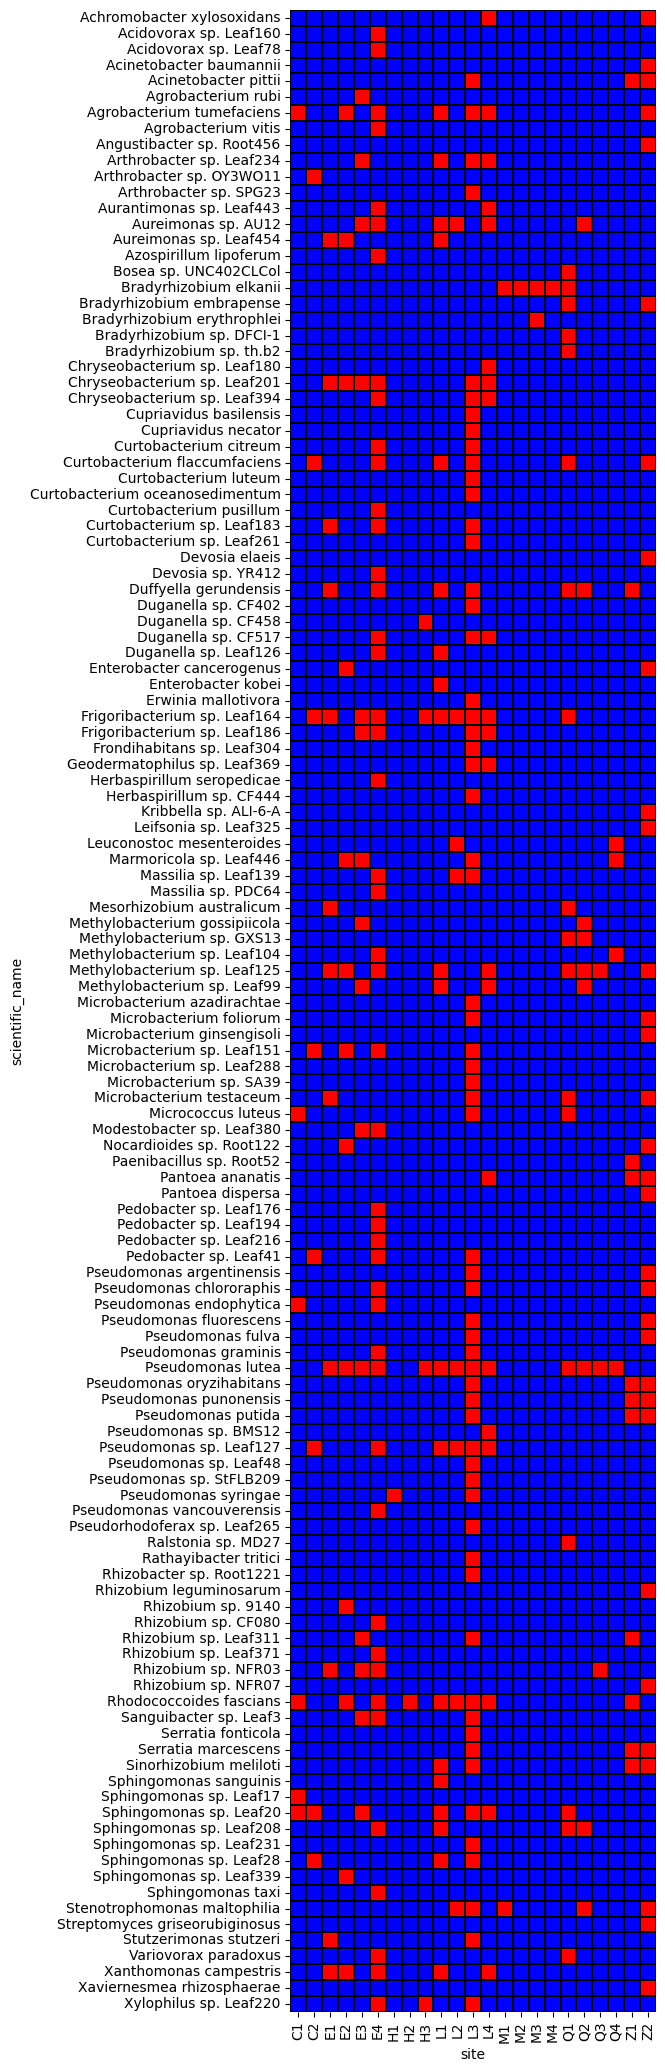

In [47]:
fig, ax = plt.subplots(1)
fig.set_size_inches(6, 26)
sns.heatmap(
    pab_hits.value_counts(['scientific_name', 'site']).reset_index().pivot(index='scientific_name', columns='site', values='count').fillna(0),
    ax=ax, vmax=1, cmap='bwr', linewidths=0.1, linecolor='black', cbar=False, square=True
)

<Axes: xlabel='site', ylabel='scientific_name'>

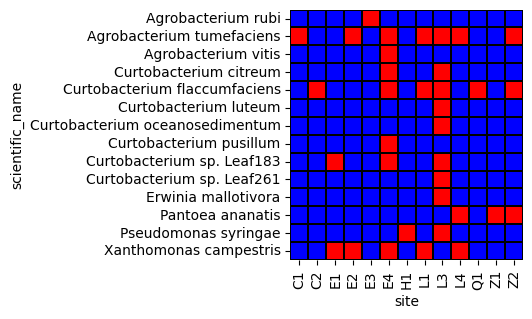

In [48]:
fig, ax = plt.subplots(1)
fig.set_size_inches(3, 4)
sns.heatmap(
    pab_hits.query('pab_type == "pab_pathogen"').value_counts(['scientific_name', 'site']).reset_index().pivot(index='scientific_name', columns='site', values='count').fillna(0),
    ax=ax, vmax=1, cmap='bwr', linewidths=0.1, linecolor='black', cbar=False, square=True
)

<Axes: xlabel='site', ylabel='scientific_name'>

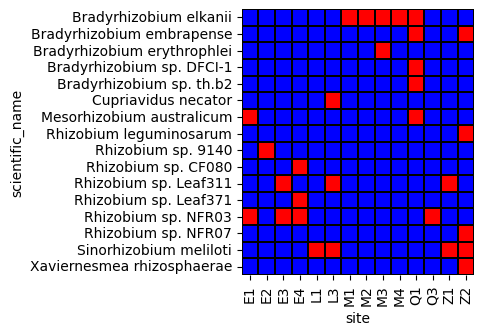

In [49]:
fig, ax = plt.subplots(1)
fig.set_size_inches(3, 4)
sns.heatmap(
    pab_hits.query('pab_type == "pab_symbiont"').value_counts(['scientific_name', 'site']).reset_index().pivot(index='scientific_name', columns='site', values='count').fillna(0),
    ax=ax, vmax=1, cmap='bwr', linewidths=0.1, linecolor='black', cbar=False, square=True
)

<Axes: xlabel='library', ylabel='scientific_name'>

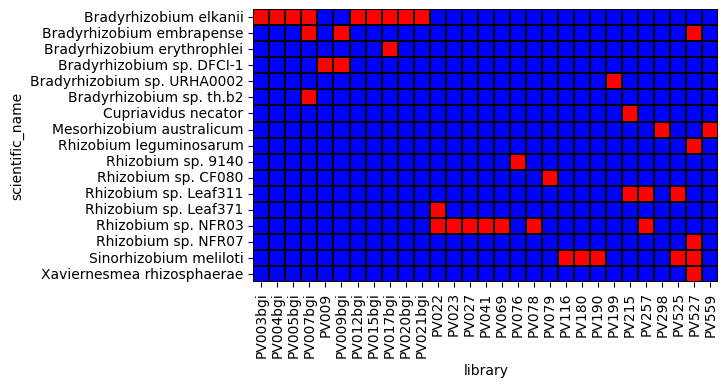

In [133]:
fig, ax = plt.subplots(1)
fig.set_size_inches(6, 7)
sns.heatmap(
    pab_hits.query('PAB_type == "symbiont"').value_counts(['scientific_name', 'library']).reset_index().pivot(index='scientific_name', columns='library', values='count').fillna(0),
    ax=ax, vmax=1, cmap='bwr', linewidths=0.1, linecolor='black', cbar=False, square=True
)

<Axes: xlabel='library', ylabel='scientific_name'>

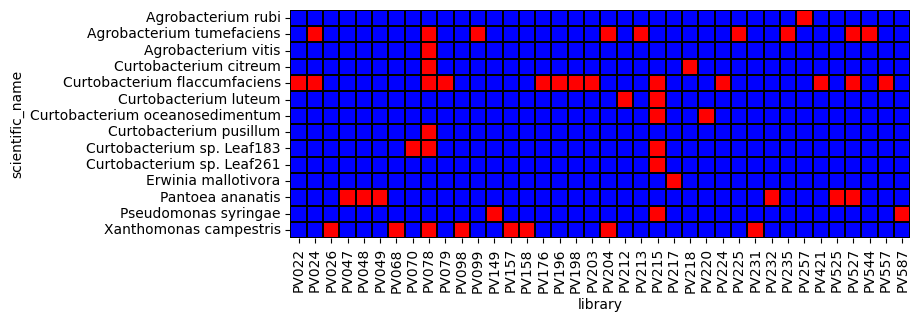

In [138]:
fig, ax = plt.subplots(1)
fig.set_size_inches(8, 6)
sns.heatmap(
    pab_hits.query('PAB_type == "pathogen"').value_counts(['scientific_name', 'library']).reset_index().pivot(index='scientific_name', columns='library', values='count').fillna(0),
    ax=ax, vmax=1, cmap='bwr', linewidths=0.1, linecolor='black', cbar=False, square=True
)